# IF3270 Pembelajaran Mesin — Tugas Besar 1
## FFNN Testing — `datasetml_2026.csv`

**Task:** Binary classification — prediksi `placement_status` (Placed / Not Placed)  
**Stack:** `model.py` · `layer.py` · `loss.py` · `activation.py` — **pure NumPy, no sklearn untuk preprocessing**

### Struktur Eksperimen
| # | Eksperimen | Yang dianalisis |
|---|-----------|-----------------|
| A | Depth & Width | Accuracy + loss curve |
| B | Fungsi Aktivasi Hidden Layer | Accuracy + loss curve + distribusi bobot & gradien |
| C | Learning Rate | Accuracy + loss curve + distribusi bobot & gradien |
| D | Regularisasi (None / L1 / L2) | Accuracy + loss curve + distribusi bobot & gradien |
| E | Perbandingan dengan sklearn MLP | Accuracy |

In [16]:
import sys, os
sys.path.insert(0, os.path.abspath("."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Implementasi sendiri — no sklearn
from model import Sequential
from layer import Dense

# sklearn HANYA untuk Experiment E (perbandingan)
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

SEED = 42
np.random.seed(SEED)
print("Imports OK")

Imports OK


## 1. EDA & Preprocessing

In [17]:
df = pd.read_csv("../data/datasetml_2026.csv")
print("Shape:", df.shape)
print(df.head())
print("\nTarget distribution:")
print(df["placement_status"].value_counts())
print("\nNull values:")
print(df.isnull().sum())

Shape: (10000, 12)
       cgpa  backlogs college_tier country university_ranking_band  \
0  7.397371         1       Tier 2  Canada                 100-300   
1  6.889389         0       Tier 3      UK                    300+   
2  7.518151         0       Tier 1      UK                 100-300   
3  8.218424         0       Tier 2      UK                 100-300   
4  6.812677         1       Tier 2     USA                 100-300   

   internship_count  aptitude_score  communication_score specialization  \
0                 2       53.574150            64.177062   Data Science   
1                 1       60.687750            88.346052   Data Science   
2                 2       64.568750            69.493171  Cybersecurity   
3                 3       73.461500            78.204854          AI/ML   
4                 4       86.518121            44.680881   Data Science   

     industry  internship_quality_score placement_status  
0  Consulting                  5.481450           

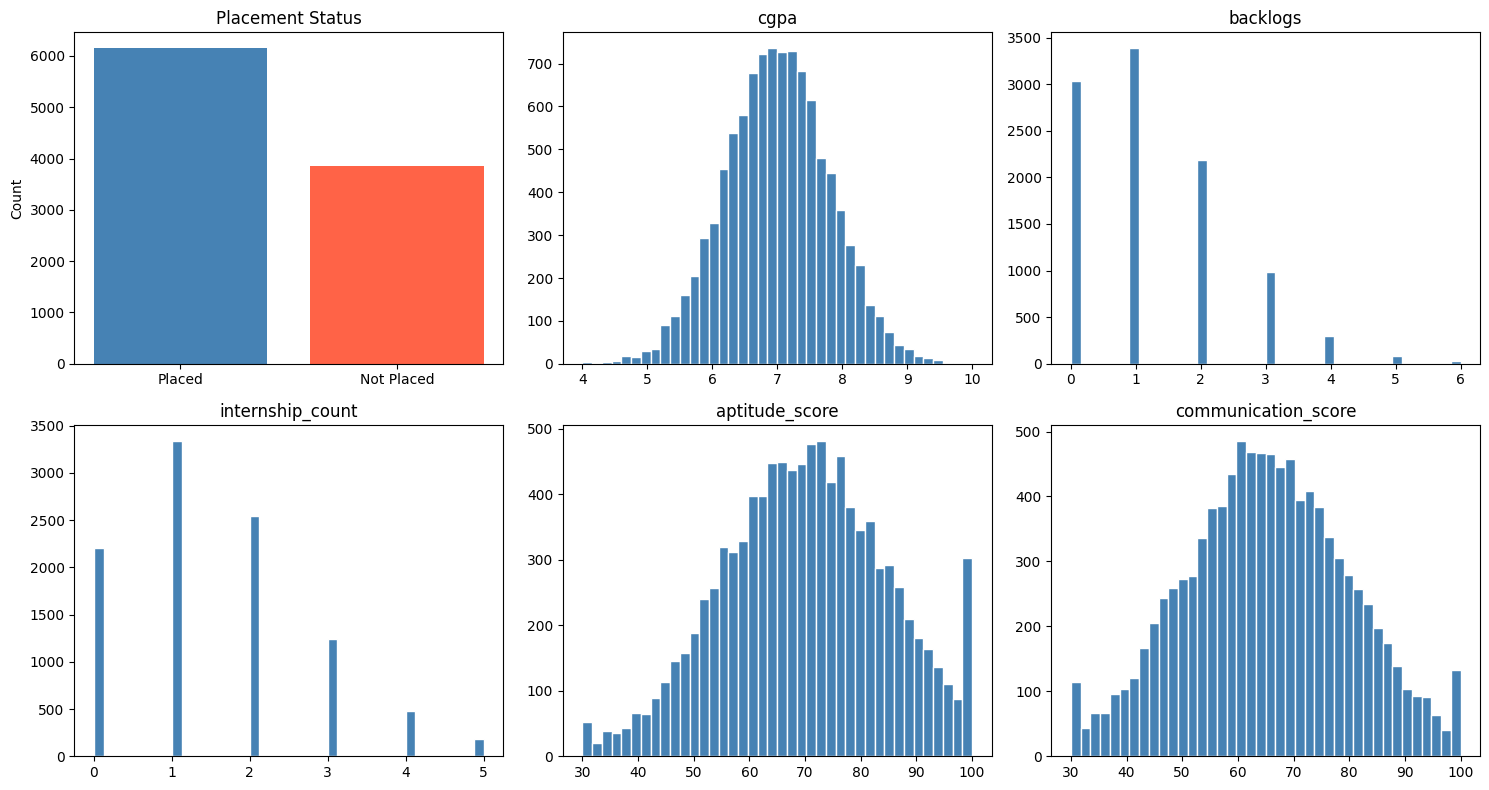

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

counts = df["placement_status"].value_counts()
axes[0].bar(counts.index, counts.values, color=["steelblue", "tomato"])
axes[0].set_title("Placement Status")
axes[0].set_ylabel("Count")

num_cols = ["cgpa", "backlogs", "internship_count",
            "aptitude_score", "communication_score", "internship_quality_score"]
for ax, col in zip(axes[1:], num_cols):
    ax.hist(df[col].values, bins=40, color="steelblue", edgecolor="white")
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [19]:
# ── Manual helpers (inline, no sklearn / utils) ────────────────────────────

def label_encode(arr):
    """String array → int codes. Returns (encoded_array, mapping_dict)."""
    unique  = sorted(set(arr.tolist()))
    mapping = {v: i for i, v in enumerate(unique)}
    return np.array([mapping[v] for v in arr], dtype=float), mapping

def zscore_fit(X):
    """Fit z-score scaler on X_train. Returns (mu, std)."""
    mu  = X.mean(axis=0)
    std = X.std(axis=0)
    std[std == 0] = 1.0
    return mu, std

def zscore_transform(X, mu, std):
    return (X - mu) / std

def manual_split(X, y, test_size=0.2, seed=42):
    """Shuffle & split into (X_train, X_test, y_train, y_test)."""
    rng   = np.random.default_rng(seed)
    idx   = rng.permutation(len(X))
    n_te  = max(1, int(len(X) * test_size))
    tr, te = idx[n_te:], idx[:n_te]
    return X[tr], X[te], y[tr], y[te]

# ── Encode categoricals ────────────────────────────────────────────────────
data = df.copy()

cat_cols = ["college_tier", "country", "university_ranking_band",
            "specialization", "industry"]
for col in cat_cols:
    data[col], _ = label_encode(data[col].values)

# ── Target: Placed=1, Not Placed=0 ────────────────────────────────────────
y_raw = (data["placement_status"] == "Placed").astype(float).values.reshape(-1, 1)

# ── Feature matrix ─────────────────────────────────────────────────────────
feature_cols = ["cgpa", "backlogs", "college_tier", "country",
                "university_ranking_band", "internship_count",
                "aptitude_score", "communication_score",
                "specialization", "industry", "internship_quality_score"]
X_raw = data[feature_cols].values.astype(float)

# ── Split: 70% train / 15% val / 15% test ─────────────────────────────────
X_tv, X_test, y_tv, y_test   = manual_split(X_raw, y_raw, test_size=0.15, seed=SEED)
X_train, X_val, y_train, y_val = manual_split(X_tv,  y_tv,  test_size=0.1765, seed=SEED)

# ── Z-score normalisation (fit on train only) ──────────────────────────────
mu, std   = zscore_fit(X_train)
X_train   = zscore_transform(X_train, mu, std)
X_val     = zscore_transform(X_val,   mu, std)
X_test    = zscore_transform(X_test,  mu, std)

N_IN = X_train.shape[1]
print(f"Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")
print(f"Placed ratio  — train: {y_train.mean():.3f}  val: {y_val.mean():.3f}  test: {y_test.mean():.3f}")

Train: (7000, 11)  Val: (1500, 11)  Test: (1500, 11)
Placed ratio  — train: 0.618  val: 0.594  test: 0.622


In [20]:
# ── Evaluation & plotting helpers ─────────────────────────────────────────

def accuracy(model, X, y_true, threshold=0.5):
    """Binary accuracy: (ŷ >= threshold) vs y_true."""
    y_pred = model.predict(X)
    preds  = (y_pred >= threshold).astype(float)
    return float(np.mean(preds == y_true))

def plot_history(histories: dict, title: str):
    """Loss curves for multiple runs on the same axes."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    for label, hist in histories.items():
        ax1.plot(hist["loss"],     label=label)
        if "val_loss" in hist:
            ax2.plot(hist["val_loss"], label=label)
    for ax, t in zip([ax1, ax2], ["Train Loss", "Val Loss"]):
        ax.set_title(f"{title} — {t}")
        ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

# Shared fit params used across all experiments
FIT_BASE = dict(
    epochs=60, batch_size=64, learning_rate=0.01,
    validation_data=(X_val, y_val), verbose=0, seed=SEED,
)
print("Helpers ready.")

Helpers ready.


## 2. Experiment A — Depth & Width
**Width variations** (depth fixed = 2 hidden layers)  
**Depth variations** (width fixed = 64 neurons per hidden layer)

Narrow  [16,16]  →  test acc = 0.7507
Medium  [64,64]  →  test acc = 0.6953
Wide    [256,256]  →  test acc = 0.6960


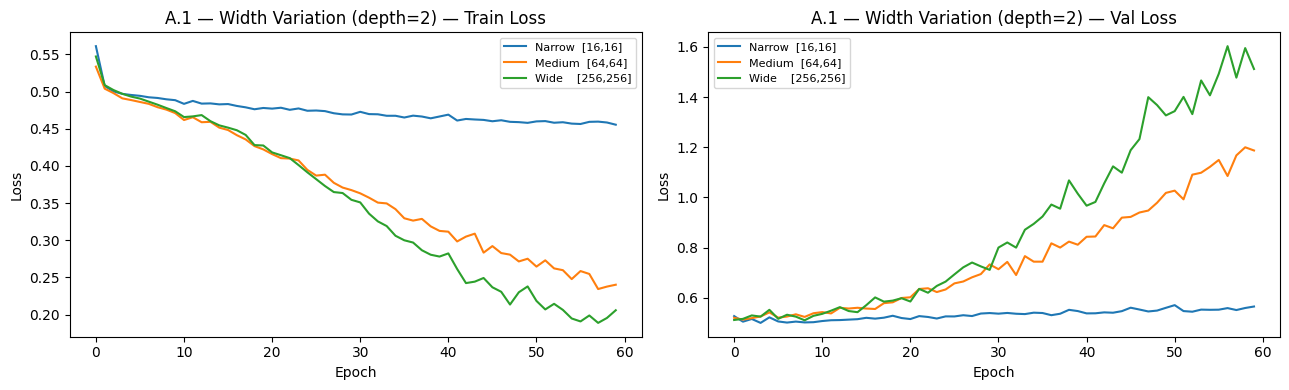

In [21]:
# ── A.1 Width variation (depth = 2 hidden layers) ─────────────────────────
width_configs = {
    "Narrow  [16,16]":   [16, 16],
    "Medium  [64,64]":   [64, 64],
    "Wide    [256,256]": [256, 256],
}

width_hist = {}
width_accs = {}
for name, hiddens in width_configs.items():
    m = Sequential()
    for h in hiddens:
        m.add(Dense(h, "relu"))
    m.add(Dense(1, "sigmoid"))
    m.compile("adam", "binary_crossentropy")
    width_hist[name] = m.fit(X_train, y_train, **FIT_BASE)
    width_accs[name] = accuracy(m, X_test, y_test)
    print(f"{name}  →  test acc = {width_accs[name]:.4f}")

plot_history(width_hist, "A.1 — Width Variation (depth=2)")

Shallow  (1 hidden)  →  test acc = 0.7553
Medium   (3 hidden)  →  test acc = 0.7067
Deep     (5 hidden)  →  test acc = 0.6907


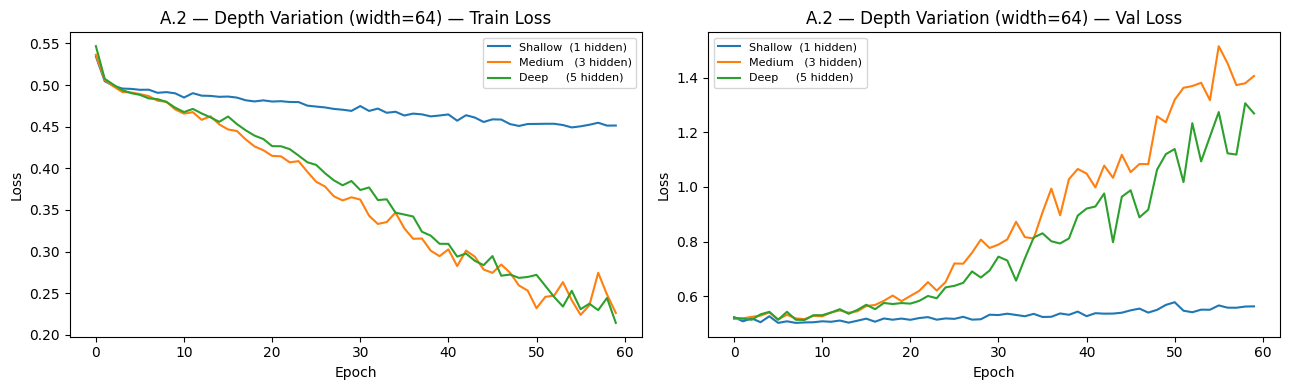

In [22]:
# ── A.2 Depth variation (width = 64 per hidden layer) ─────────────────────
depth_configs = {
    "Shallow  (1 hidden)": [64],
    "Medium   (3 hidden)": [64, 64, 64],
    "Deep     (5 hidden)": [64, 64, 64, 64, 64],
}

depth_hist = {}
depth_accs = {}
for name, hiddens in depth_configs.items():
    m = Sequential()
    for h in hiddens:
        m.add(Dense(h, "relu"))
    m.add(Dense(1, "sigmoid"))
    m.compile("adam", "binary_crossentropy")
    depth_hist[name] = m.fit(X_train, y_train, **FIT_BASE)
    depth_accs[name] = accuracy(m, X_test, y_test)
    print(f"{name}  →  test acc = {depth_accs[name]:.4f}")

plot_history(depth_hist, "A.2 — Depth Variation (width=64)")

In [23]:
# ── A summary table ─────────────────────────────────────────────────────────
rows = [{"Config": k, "Type": "Width", "Test Acc": v} for k, v in width_accs.items()]
rows += [{"Config": k, "Type": "Depth", "Test Acc": v} for k, v in depth_accs.items()]
pd.DataFrame(rows).sort_values("Test Acc", ascending=False).reset_index(drop=True)

,Config,Type,Test Acc
0,Shallow (1 hidden),Depth,0.755333
1,"Narrow [16,16]",Width,0.750667
2,Medium (3 hidden),Depth,0.706667
3,"Wide [256,256]",Width,0.696000
4,"Medium [64,64]",Width,0.695333
5,Deep (5 hidden),Depth,0.690667


## 3. Experiment B — Activation Functions (Hidden Layers)
Base architecture: `[N_IN → 128 → 64 → 32 → 1]`.  
Layer 2 (index 1, i.e. the 64-neuron layer) is the test layer — its activation is varied.  
Candidates: `linear`, `relu`, `sigmoid`, `tanh` (softmax excluded for hidden layers).

act=linear    →  test acc = 0.7240
act=relu      →  test acc = 0.6927
act=sigmoid   →  test acc = 0.6953
act=tanh      →  test acc = 0.7307


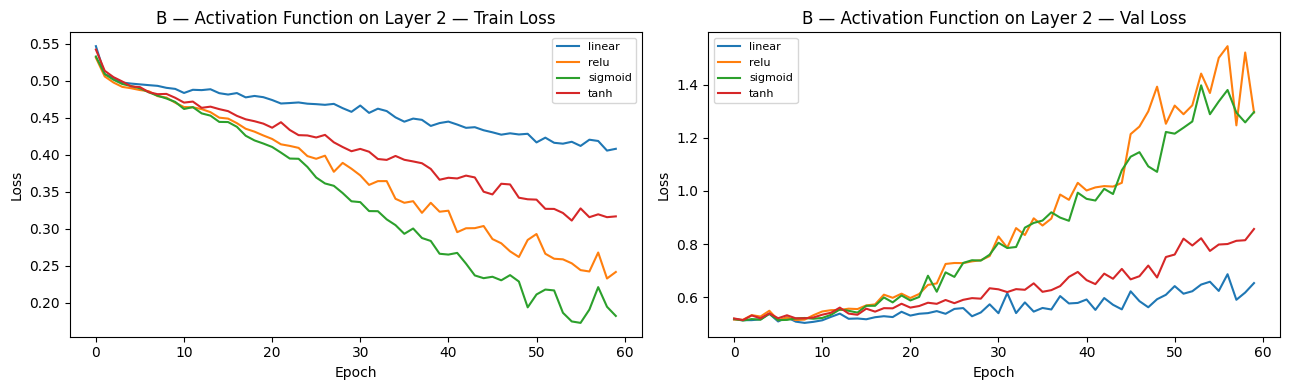

In [24]:
# ── B Activation function experiment ───────────────────────────────────────
# Base arch: N_IN → 128 → 64 → 32 → 1
# Layer ke-2 (64 neuron) activation-nya divariasikan
test_activations = ["linear", "relu", "sigmoid", "tanh"]

act_hist   = {}
act_accs   = {}
act_models = {}

for act in test_activations:
    m = Sequential()
    m.add(Dense(128, "relu"))
    m.add(Dense(64,  act))       # ← activation divariasikan
    m.add(Dense(32,  "relu"))
    m.add(Dense(1,   "sigmoid"))
    m.compile("adam", "binary_crossentropy")
    act_hist[act]   = m.fit(X_train, y_train, **FIT_BASE)
    act_accs[act]   = accuracy(m, X_test, y_test)
    act_models[act] = m
    print(f"act={act:<8}  →  test acc = {act_accs[act]:.4f}")

plot_history(act_hist, "B — Activation Function on Layer 2")


── Activation = linear ──


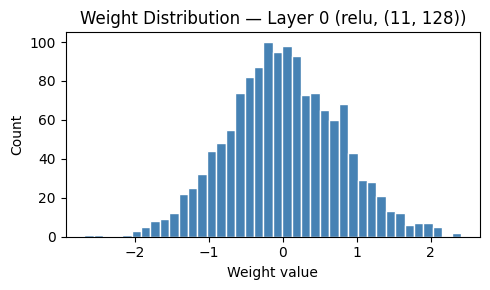

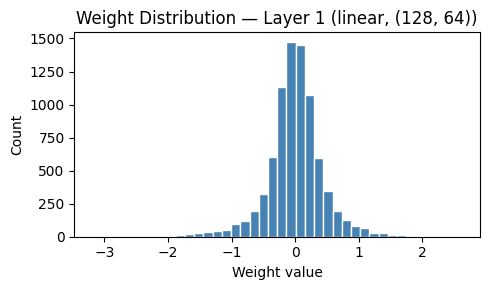

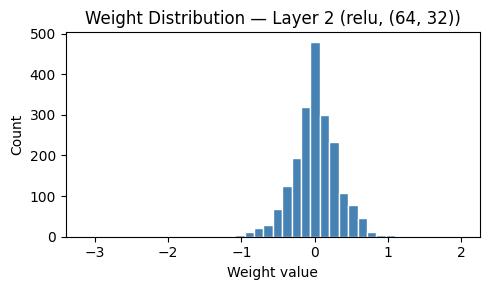

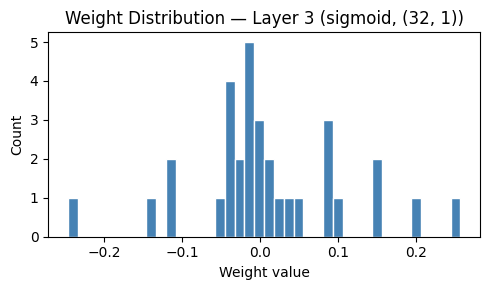

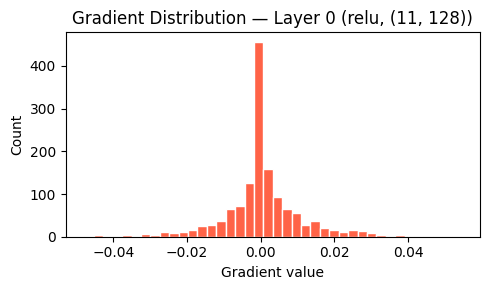

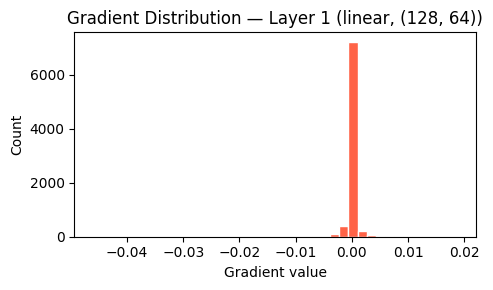

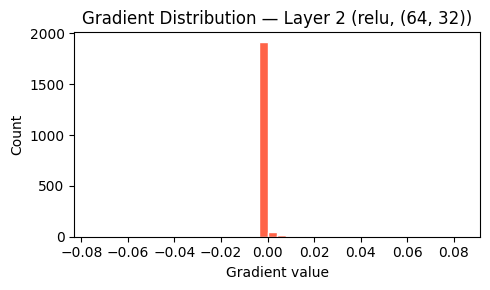

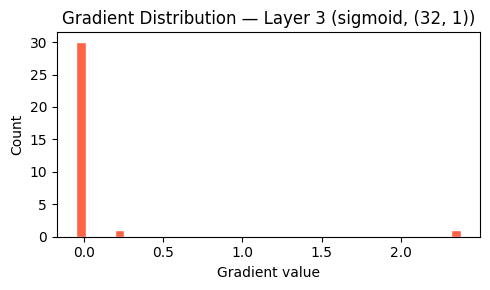


── Activation = relu ──


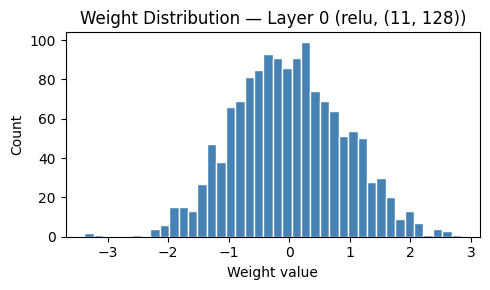

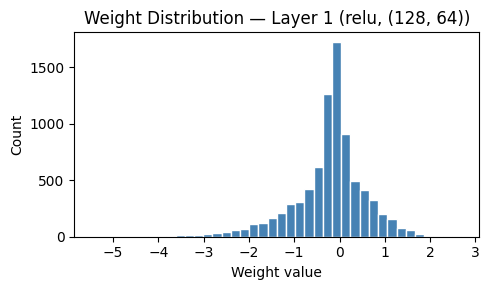

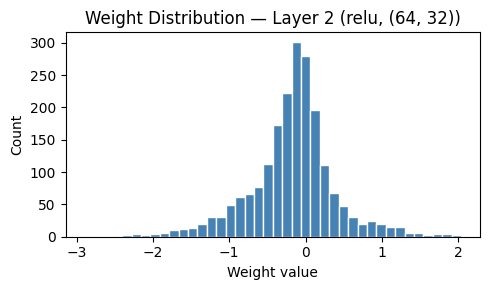

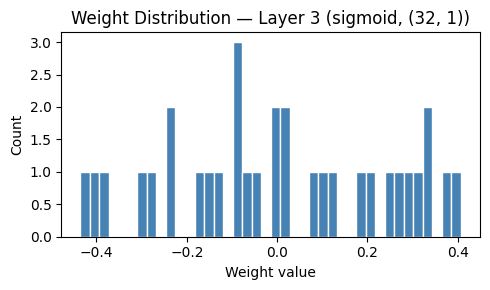

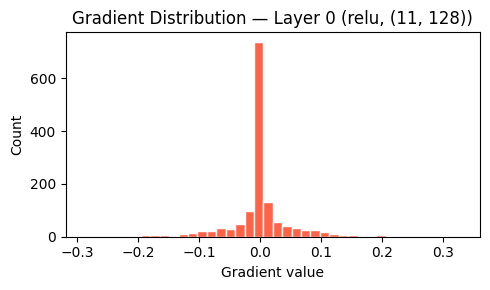

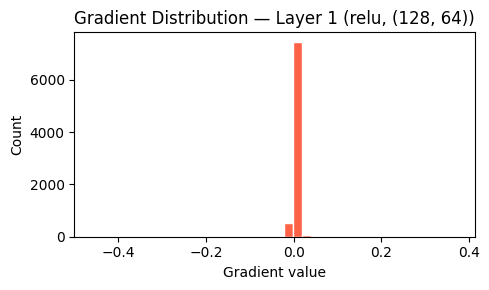

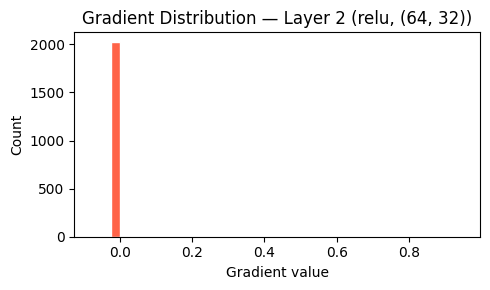

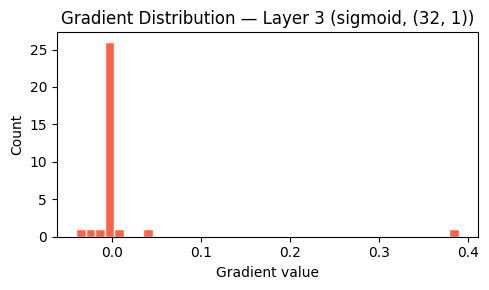


── Activation = sigmoid ──


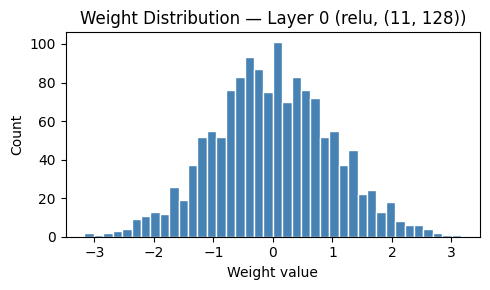

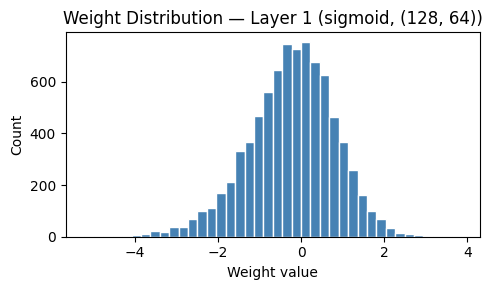

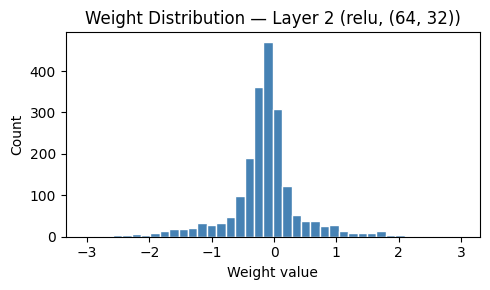

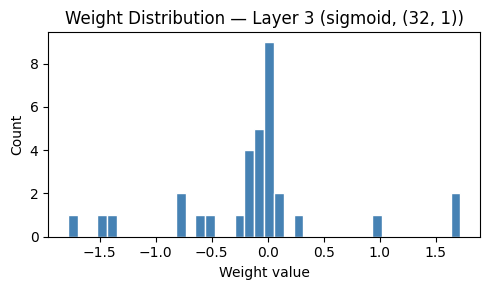

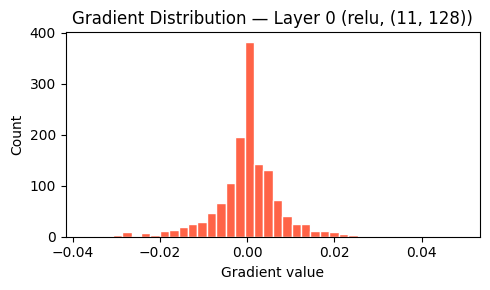

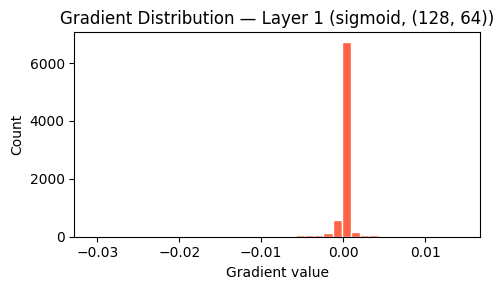

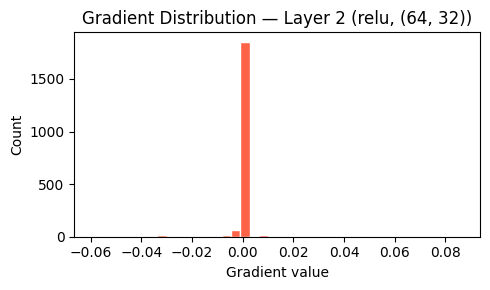

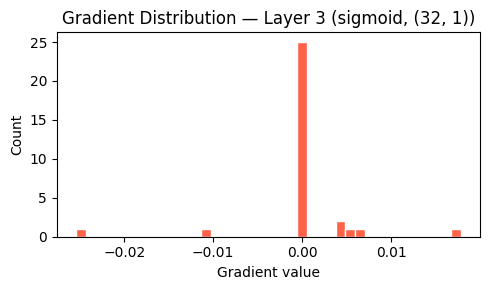


── Activation = tanh ──


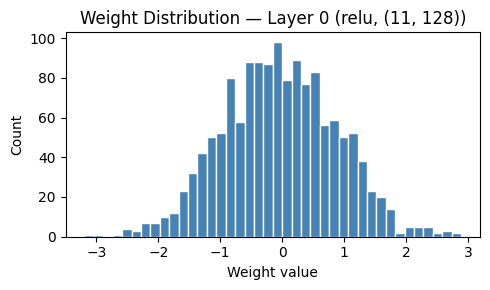

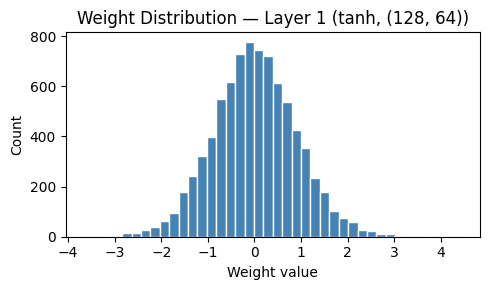

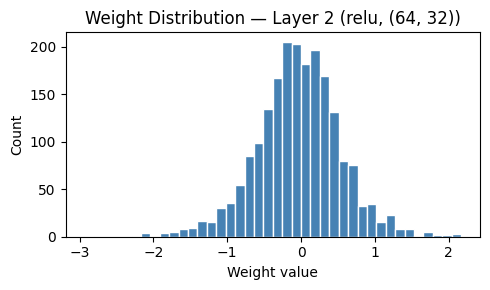

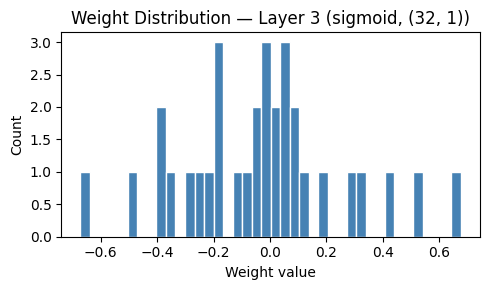

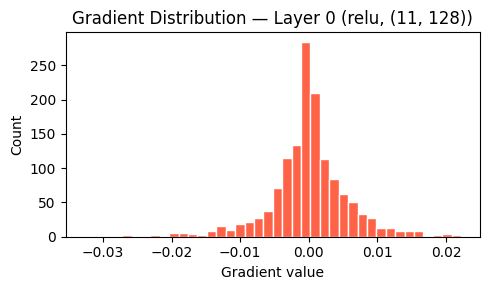

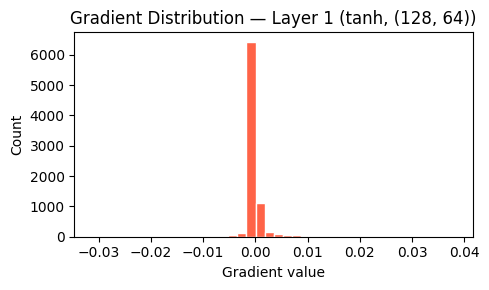

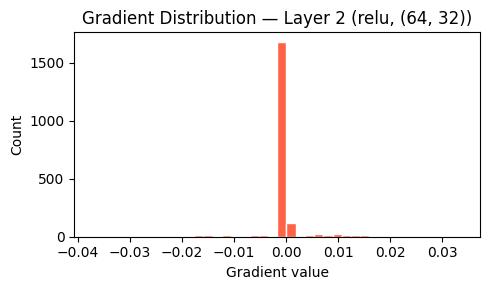

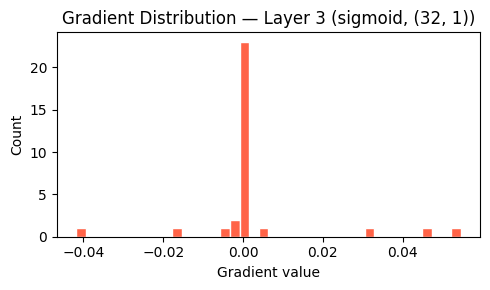

,Activation,Test Acc
0,tanh,0.730667
1,linear,0.724000
2,sigmoid,0.695333
3,relu,0.692667


In [25]:
# ── B  Weight & gradient distributions for all models ──────────────────────
for act, model in act_models.items():
    print(f"\n── Activation = {act} ──")
    model.plot_weight_distribution(layers=[0, 1, 2, 3])
    model.plot_gradient_distribution(layers=[0, 1, 2, 3])

# Summary table
pd.DataFrame({"Activation": list(act_accs.keys()),
              "Test Acc":   list(act_accs.values())}).sort_values("Test Acc", ascending=False).reset_index(drop=True)

## Experiment C — Learning Rate
Arsitektur tetap: `[N_IN → 64 → 32 → 1]`, optimizer Adam.  
3 variasi: `lr ∈ {0.1, 0.01, 0.001}`

lr=0.1  →  test acc = 0.6220
lr=0.01  →  test acc = 0.7313
lr=0.001  →  test acc = 0.7533


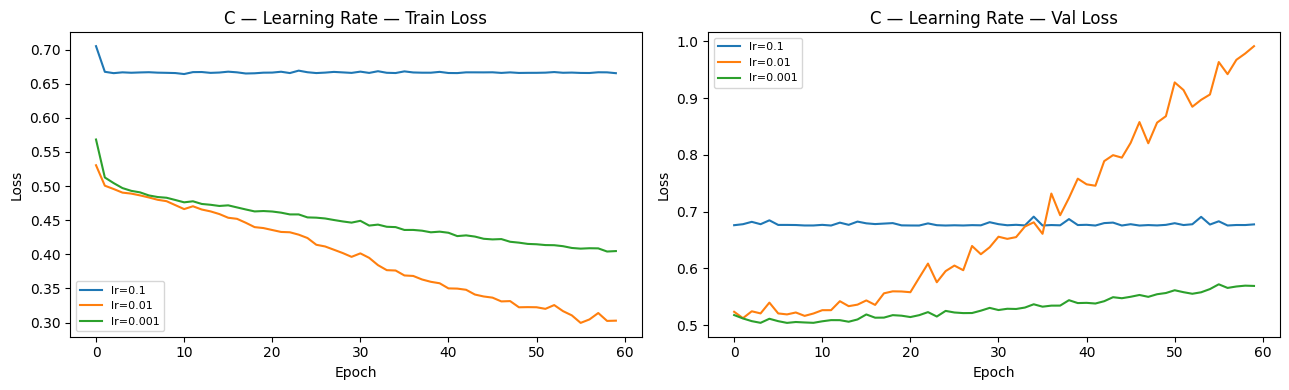

Learning Rate Test Acc
       lr=0.1   0.6220
      lr=0.01   0.7313
     lr=0.001   0.7533

=== Distribusi Bobot (Weight Distribution) ===

── lr=0.1 ──


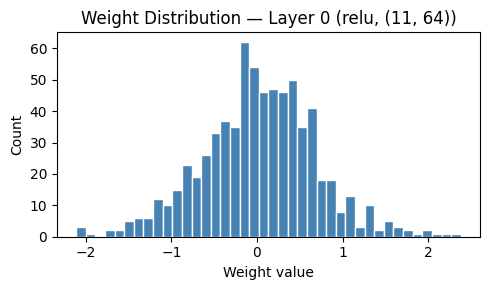

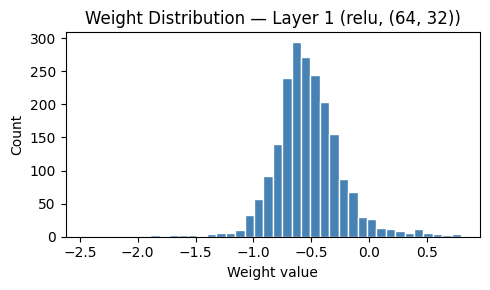


── lr=0.01 ──


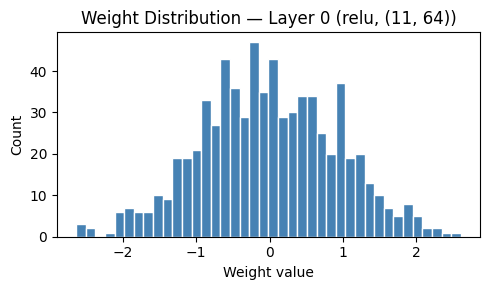

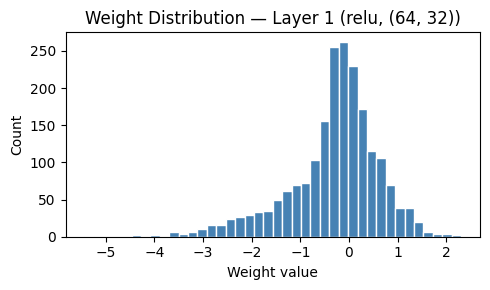


── lr=0.001 ──


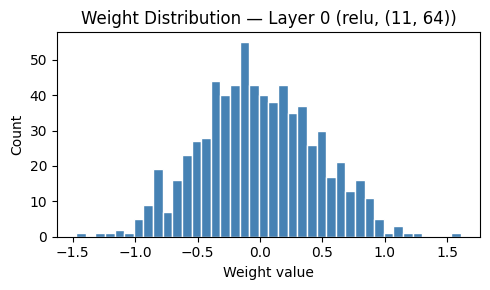

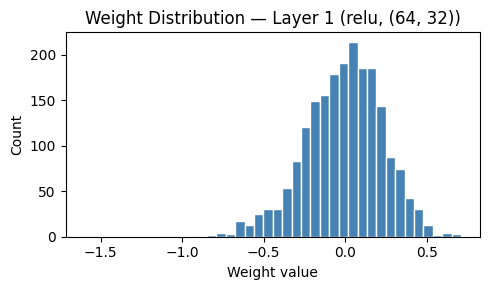


=== Distribusi Gradien (Gradient Distribution) ===

── lr=0.1 ──


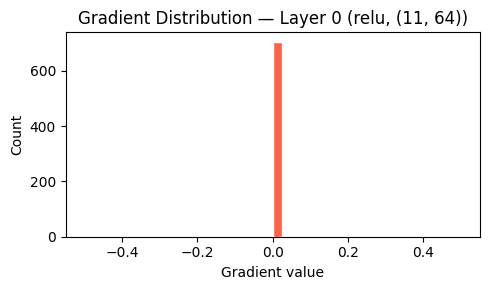

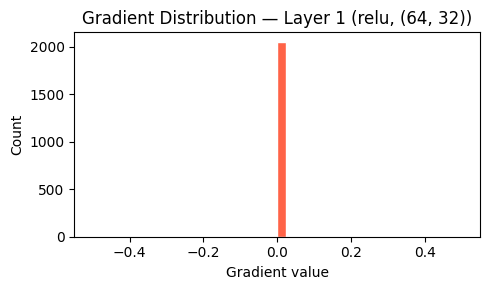


── lr=0.01 ──


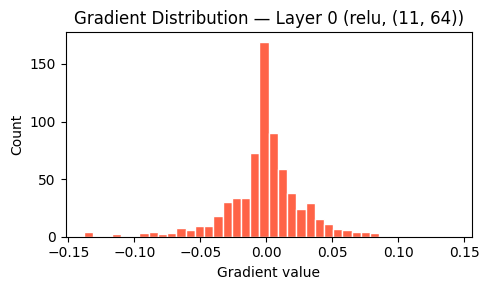

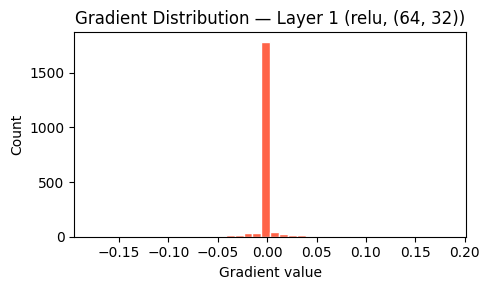


── lr=0.001 ──


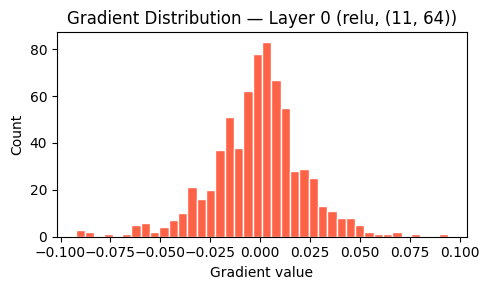

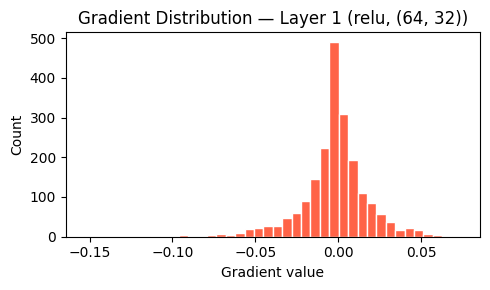

In [26]:
# ── C Learning rate experiment ────────────────────────────────────────────
# 3 variasi learning rate, arsitektur: N_IN → 64 → 32 → 1
learning_rates = [0.1, 0.01, 0.001]

lr_hist   = {}
lr_accs   = {}
lr_models = {}

for lr in learning_rates:
    m = Sequential()
    m.add(Dense(64, "relu"))
    m.add(Dense(32, "relu"))
    m.add(Dense(1,  "sigmoid"))
    m.compile("adam", "binary_crossentropy")
    lr_hist[f"lr={lr}"] = m.fit(
        X_train, y_train,
        epochs=60, batch_size=64, learning_rate=lr,
        validation_data=(X_val, y_val), verbose=0, seed=SEED
    )
    lr_accs[f"lr={lr}"]   = accuracy(m, X_test, y_test)
    lr_models[f"lr={lr}"] = m
    print(f"lr={lr}  →  test acc = {lr_accs[f'lr={lr}']:.4f}")

plot_history(lr_hist, "C — Learning Rate")

# Accuracy summary
df_c = pd.DataFrame({
    "Learning Rate": list(lr_accs.keys()),
    "Test Acc":      [f"{v:.4f}" for v in lr_accs.values()]
}).reset_index(drop=True)
print(df_c.to_string(index=False))

# ── C Distribusi Bobot ────────────────────────────────────────────────────
print("\n=== Distribusi Bobot (Weight Distribution) ===")
for name, model in lr_models.items():
    print(f"\n── {name} ──")
    model.plot_weight_distribution(layers=[0, 1])

# ── C Distribusi Gradien ──────────────────────────────────────────────────
print("\n=== Distribusi Gradien (Gradient Distribution) ===")
for name, model in lr_models.items():
    print(f"\n── {name} ──")
    model.plot_gradient_distribution(layers=[0, 1])

## Experiment D — Regularisasi
Arsitektur: `[N_IN → 128 → 64 → 1]`.  
Variasi: tanpa reg / L1 / L2 / L1+L2

No Reg        →  test acc = 0.7187
L1=0.001      →  test acc = 0.7673
L2=0.001      →  test acc = 0.7547


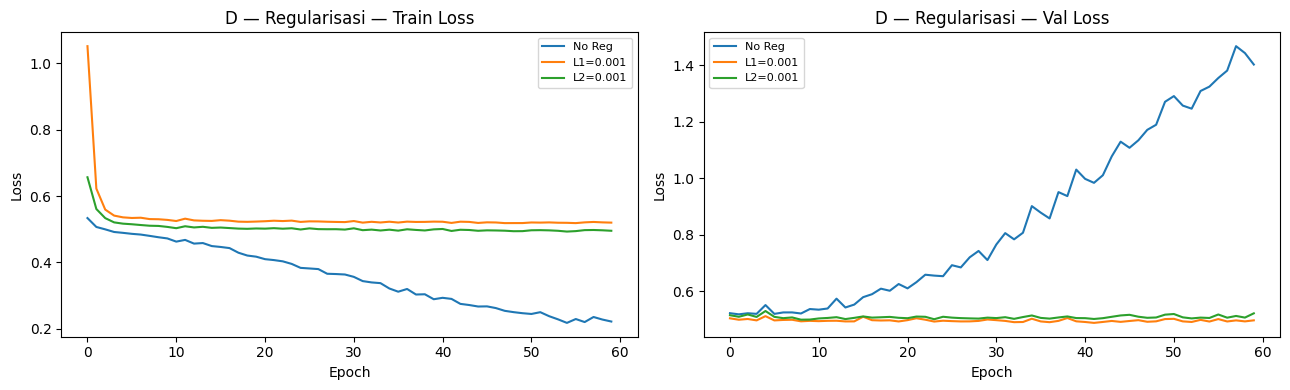

Regularisasi Test Acc
      No Reg   0.7187
    L1=0.001   0.7673
    L2=0.001   0.7547

=== Distribusi Bobot (Weight Distribution) ===

── No Reg ──


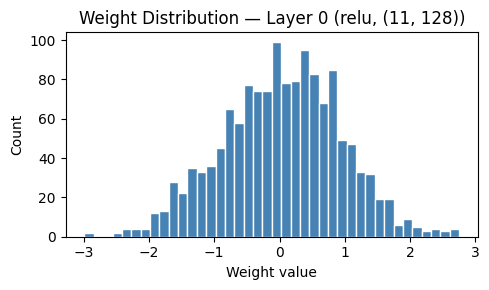

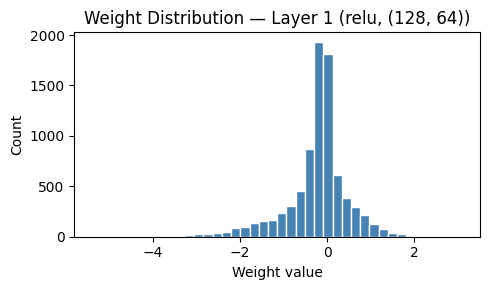


── L1=0.001 ──


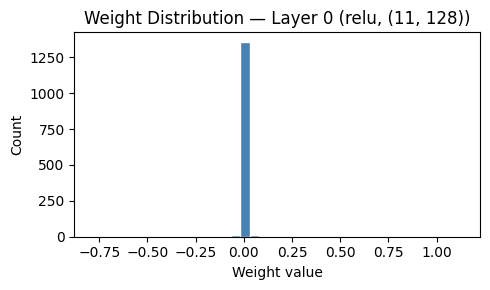

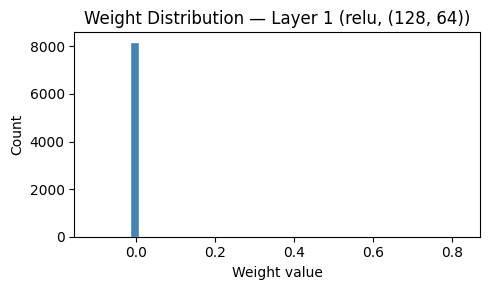


── L2=0.001 ──


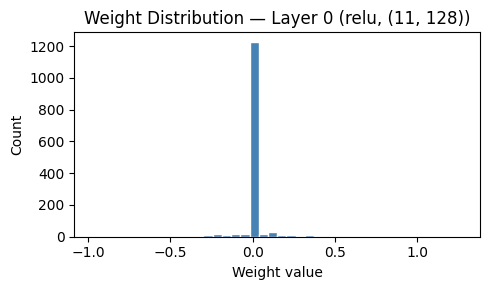

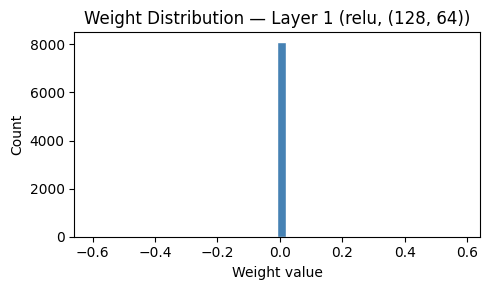


=== Distribusi Gradien (Gradient Distribution) ===

── No Reg ──


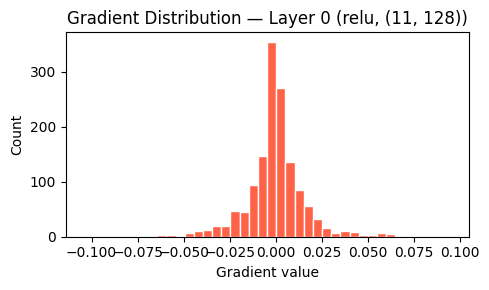

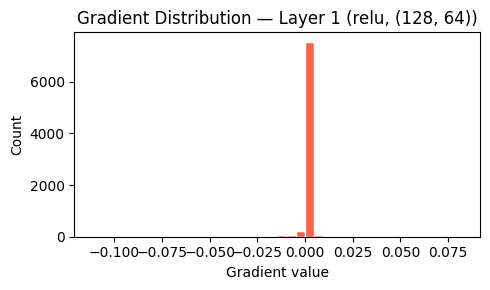


── L1=0.001 ──


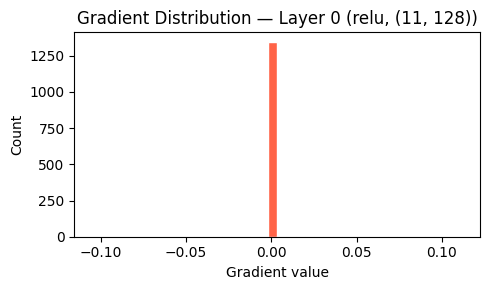

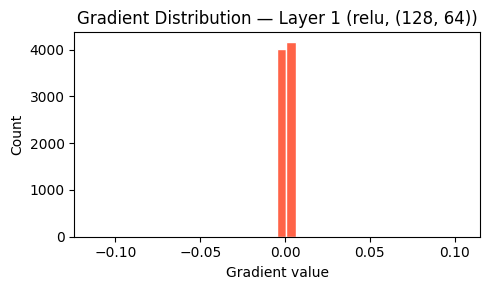


── L2=0.001 ──


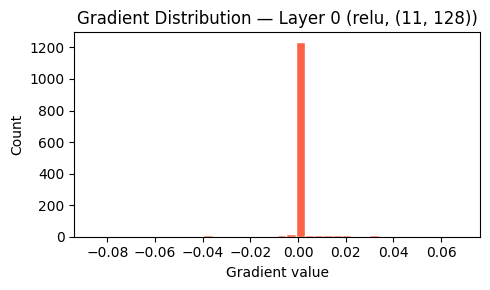

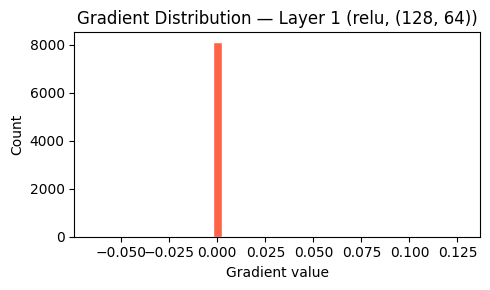

In [27]:
# ── D Regularisation experiment ───────────────────────────────────────────
# Arsitektur: N_IN → 128 → 64 → 1
# 3 kondisi: tanpa reg / L1 / L2

reg_configs = {
    "No Reg":   dict(l1=0.0,   l2=0.0),
    "L1=0.001": dict(l1=0.001, l2=0.0),
    "L2=0.001": dict(l1=0.0,   l2=0.001),
}

reg_hist   = {}
reg_accs   = {}
reg_models = {}

for name, reg in reg_configs.items():
    m = Sequential()
    m.add(Dense(128, "relu", l1=reg["l1"], l2=reg["l2"]))
    m.add(Dense(64,  "relu", l1=reg["l1"], l2=reg["l2"]))
    m.add(Dense(1, "sigmoid"))
    m.compile("adam", "binary_crossentropy")
    reg_hist[name]   = m.fit(X_train, y_train, **FIT_BASE)
    reg_accs[name]   = accuracy(m, X_test, y_test)
    reg_models[name] = m
    print(f"{name:<12}  →  test acc = {reg_accs[name]:.4f}")

plot_history(reg_hist, "D — Regularisasi")

# Accuracy summary
df_d = pd.DataFrame({
    "Regularisasi": list(reg_accs.keys()),
    "Test Acc":     [f"{v:.4f}" for v in reg_accs.values()]
}).reset_index(drop=True)
print(df_d.to_string(index=False))

# ── D Distribusi Bobot ────────────────────────────────────────────────────
print("\n=== Distribusi Bobot (Weight Distribution) ===")
for name, model in reg_models.items():
    print(f"\n── {name} ──")
    model.plot_weight_distribution(layers=[0, 1])

# ── D Distribusi Gradien ──────────────────────────────────────────────────
print("\n=== Distribusi Gradien (Gradient Distribution) ===")
for name, model in reg_models.items():
    print(f"\n── {name} ──")
    model.plot_gradient_distribution(layers=[0, 1])

## Experiment E — Perbandingan dengan sklearn MLP
Satu kali pelatihan dengan **hyperparameter yang sama** untuk kedua model.  
Hanya membandingkan **hasil akhir prediksi** (accuracy).

In [28]:
# ── E Hyperparameter yang sama untuk kedua model ─────────────────────────
# Arsitektur: 2 hidden layers masing-masing 64 neuron, relu, adam, lr=0.01, epochs=60

# ── E.1 Model kita sendiri (FFNN from scratch) ────────────────────────────
our_model = Sequential()
our_model.add(Dense(64, "relu"))
our_model.add(Dense(32, "relu"))
our_model.add(Dense(1,  "sigmoid"))
our_model.compile("adam", "binary_crossentropy")
our_model.fit(
    X_train, y_train,
    epochs=60, batch_size=64, learning_rate=0.01,
    validation_data=(X_val, y_val), verbose=0, seed=SEED
)
our_pred = (our_model.predict(X_test) >= 0.5).astype(int).ravel()
our_acc  = float(np.mean(our_pred == y_test.ravel().astype(int)))

# ── E.2 sklearn MLPClassifier ─────────────────────────────────────────────
# max_iter=60 ekuivalen epochs, hidden_layer_sizes=(64, 32)
sklearn_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    learning_rate_init=0.01,
    max_iter=60,
    batch_size=64,
    random_state=SEED,
    early_stopping=False,
)
sklearn_model.fit(X_train, y_train.ravel().astype(int))
sklearn_pred = sklearn_model.predict(X_test)
sklearn_acc  = accuracy_score(y_test.ravel().astype(int), sklearn_pred)

# ── Hasil perbandingan ────────────────────────────────────────────────────
print("=" * 40)
print("PERBANDINGAN HASIL PREDIKSI (Test Accuracy)")
print("=" * 40)
print(f"{'FFNN from scratch':<25}: {our_acc:.4f}")
print(f"{'sklearn MLPClassifier':<25}: {sklearn_acc:.4f}")
print("=" * 40)

df_e = pd.DataFrame({
    "Model":    ["FFNN (from scratch)", "sklearn MLPClassifier"],
    "Test Acc": [f"{our_acc:.4f}", f"{sklearn_acc:.4f}"]
})
print(df_e.to_string(index=False))

PERBANDINGAN HASIL PREDIKSI (Test Accuracy)
FFNN from scratch        : 0.7313
sklearn MLPClassifier    : 0.7200
                Model Test Acc
  FFNN (from scratch)   0.7313
sklearn MLPClassifier   0.7200


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (60) reached and the optimization hasn't converged yet.
  warnings.warn(


---
## Rekap Semua Eksperimen

In [29]:
all_results = {}
all_results.update({f"[A-Width] {k}": v for k, v in width_accs.items()})
all_results.update({f"[A-Depth] {k}": v for k, v in depth_accs.items()})
all_results.update({f"[B-Act]   act={k}": v for k, v in act_accs.items()})
all_results.update({f"[C-LR]    {k}": v for k, v in lr_accs.items()})
all_results.update({f"[D-Reg]   {k}": v for k, v in reg_accs.items()})
all_results.update({
    "[E-Comp]  FFNN (ours)":    our_acc,
    "[E-Comp]  sklearn MLP":    sklearn_acc,
})

df_recap = pd.DataFrame({
    "Konfigurasi": list(all_results.keys()),
    "Test Acc":    [f"{v:.4f}" for v in all_results.values()]
}).sort_values("Test Acc", ascending=False).reset_index(drop=True)

print(df_recap.to_string(index=False))

                  Konfigurasi Test Acc
           [D-Reg]   L1=0.001   0.7673
[A-Depth] Shallow  (1 hidden)   0.7553
           [D-Reg]   L2=0.001   0.7547
           [C-LR]    lr=0.001   0.7533
    [A-Width] Narrow  [16,16]   0.7507
            [C-LR]    lr=0.01   0.7313
        [E-Comp]  FFNN (ours)   0.7313
           [B-Act]   act=tanh   0.7307
         [B-Act]   act=linear   0.7240
        [E-Comp]  sklearn MLP   0.7200
             [D-Reg]   No Reg   0.7187
[A-Depth] Medium   (3 hidden)   0.7067
  [A-Width] Wide    [256,256]   0.6960
        [B-Act]   act=sigmoid   0.6953
    [A-Width] Medium  [64,64]   0.6953
           [B-Act]   act=relu   0.6927
[A-Depth] Deep     (5 hidden)   0.6907
             [C-LR]    lr=0.1   0.6220
